In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, classification_report, accuracy_score, ConfusionMatrixDisplay
from pathlib import Path
import seaborn as sns
from matplotlib import pyplot as plt
base_path = Path('/content/drive/MyDrive/solvro_dane')

In [ ]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

In [ ]:
titanic_df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [ ]:
titanic_df = titanic_df.drop(columns = ["Name","Ticket","Cabin","Embarked"])
missing_ages = titanic_df["Age"].isna()
missing_prices = titanic_df["Fare"].isna()
titanic_df.loc[missing_ages,"Age"] = titanic_df["Age"].median()
titanic_df.loc[missing_prices,"Fare"] = titanic_df["Fare"].median()
missing_rows=titanic_df.isna().sum(axis = 0)
titanic_df['Sex'] = titanic_df['Sex'].map({'male': 0, 'female': 1})
titanic_df["Age"]=titanic_df["Age"].astype(int)
titanic_df["Is_Old"] = (titanic_df["Age"] > np.median(titanic_df["Age"])).astype(int)
titanic_df["Ticket_Price"] = (titanic_df["Fare"] > np.median(titanic_df["Fare"])).astype(int)
titanic_df["Has_Family"] = np.where((titanic_df["SibSp"] > 0) | (titanic_df["Parch"] > 0), 1, 0)
titanic_df.drop(columns=["SibSp", "Parch"], inplace=True)
titanic_df

,Survived,Pclass,Sex,Age,Fare,Is_Old,Ticket_Price,Has_Family
PassengerId,,,,,,,,
1,0,3,0,22,7.2500,0,0,1
2,1,1,1,38,71.2833,1,1,1
3,1,3,1,26,7.9250,0,0,0
4,1,1,1,35,53.1000,1,1,1
5,0,3,0,35,8.0500,1,0,0
...,...,...,...,...,...,...,...,...
887,0,2,0,27,13.0000,0,0,0
888,1,1,1,19,30.0000,0,1,0
889,0,3,1,28,23.4500,0,1,1


  Zaczniemy od określenia cech oraz etykiet do naszych modeli. Etykietą bedzie kolumna "Survived", a cechami reszta kolumn z wyłączeniem age i fare, które usunimey gdyż są ciągłe a nie dyskretne, na ich miejsce mamy juz kolumny is_old oraz ticket_price. Następnie podzielimy dane na treningowe i testowe 80-20.

In [ ]:
y = titanic_df["Survived"]
x = titanic_df.drop(columns=["Survived","Age","Fare"])
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

Będę tworzył 3 modele, w których metryki i wizualizacje będą się powtarzać, więc stworzyłem funkcję ewaluacyjną aby nie powtarzać kodu. Metryki, które wybrałem to dokładność modelu - ponieważ predykowane klasy w danych titanica są w miare zbalansowane, a wskazaknie danej klasy nie jest sprawą "życia i śmierci" jak np. w przypadku klasyfikowania czy pacjent jest chory czy zdrowy, więc dokładność powinna dobrze się sprawdzić. Oprócz dokładości druga metryką będzie wizualizacja macierzy pomyłek do zobaczenia, przy predykowaniu któej klasy modele się mylą częscięj. Dodatkowo wyświeltalm ogólny raport klasyfikacji.

In [ ]:
def model_evaluation(y_test,y_pred):
  print(f"Skuteczność modelu wynosi: {accuracy_score(y_test,y_pred)}")
  ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred)).plot()
  plt.xlabel("Przewidywane etykiety")
  plt.ylabel("Prawdziwe etykiety")
  plt.title("Macierz pomyłek")
  plt.show()
  print(classification_report(y_test,y_pred))

Zaczynamy od sprawdzenia modelu DummyClassifier, aby móc potem do niego porównywać skuteczność modeli

Skuteczność modelu wynosi: 0.48044692737430167


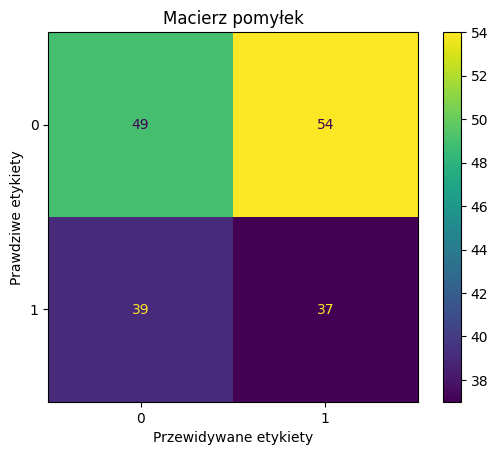

              precision    recall  f1-score   support

           0       0.56      0.48      0.51       103
           1       0.41      0.49      0.44        76

    accuracy                           0.48       179
   macro avg       0.48      0.48      0.48       179
weighted avg       0.49      0.48      0.48       179



In [ ]:
model = DummyClassifier(strategy = 'uniform')
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
model_evaluation(y_test,y_pred)

Pierwszym modelem klasyfikacji będzie drzewo decyzyjne. Skuteczność modelu przy deafultowych parametrach wynosi 74% - czyli jest lepiej niż przy beźmyślnym strzelaniu. Na macierzy pomyłek mozęmy zoabczyć, że model przy predykowaniu klasy 0 radzi sobie dość dobrze, tak przy predykowaniu klasy 1 skuteczność jest już dużo niższa co nie świadczy dobrze. Model przewiduje zdecydowanie częściej klasę 0 niż klasę 1.

Skuteczność modelu wynosi: 0.7430167597765364


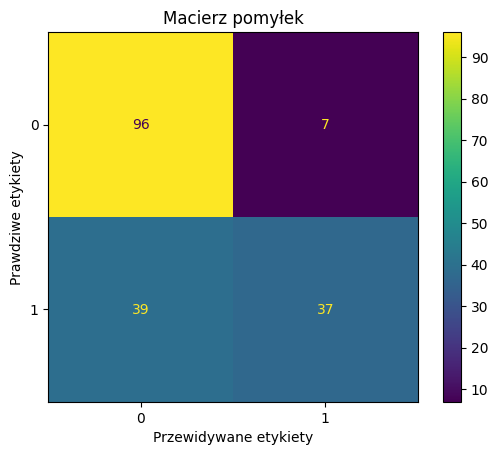

              precision    recall  f1-score   support

           0       0.71      0.93      0.81       103
           1       0.84      0.49      0.62        76

    accuracy                           0.74       179
   macro avg       0.78      0.71      0.71       179
weighted avg       0.77      0.74      0.73       179



In [ ]:
model = DecisionTreeClassifier(random_state=42)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
model_evaluation(y_test,y_pred)

Kolejnym modelem, który wybrałem jest SVM, gdzie zastosowałem również standaryzację cech. Wyniki są podobne do drzewa decyzyjnego

Skuteczność modelu wynosi: 0.7541899441340782


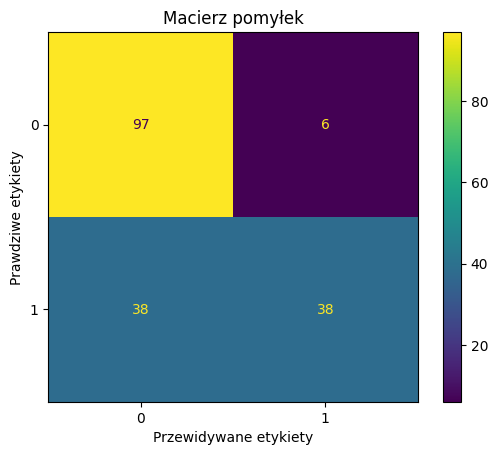

              precision    recall  f1-score   support

           0       0.72      0.94      0.82       103
           1       0.86      0.50      0.63        76

    accuracy                           0.75       179
   macro avg       0.79      0.72      0.72       179
weighted avg       0.78      0.75      0.74       179



In [ ]:
clf = make_pipeline(StandardScaler(), SVC())
clf.fit(x_train,y_train)
y_pred = clf.predict(x_test)
model_evaluation